# Homework 3

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

For the econometric analysis, we use the datasets from the folder 70701808

## Packages

In [7]:
library(fst)
library(highfrequency)
library(xts)

Warning message:
"package 'fst' was built under R version 4.5.3"
Warning message:
"package 'highfrequency' was built under R version 4.5.3"
Warning message:
"package 'xts' was built under R version 4.5.2"
Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric




## Data import

In [8]:
dates<-read.csv("students_HW3/70701808_periods_HW_3.csv")
msft<-read.fst("HW_3_data/HW_3_MSFT_1min.fst")
bac<-read.fst("HW_3_data/HW_3_BAC_1min.fst")
xom<-read.fst("HW_3_data/HW_3_XOM_1min.fst")

Warning message:
"package 'fstcore' was built under R version 4.5.3"


In [9]:
head(dates)

,X,Ticker,Start,End
,<int>,<chr>,<int>,<int>
1,1,MSFT,2011,2016
2,2,BAC,2012,2016
3,3,XOM,2015,2016


In [10]:
print(dim(msft))
head(msft)

[1] 933337      2


,index,V1
,<dttm>,<dbl>
1,2010-01-04 07:44:00,24.6994
2,2010-01-04 07:56:00,24.6673
3,2010-01-04 08:00:00,24.6593
4,2010-01-04 08:01:00,24.6272
5,2010-01-04 08:05:00,24.6192
6,2010-01-04 08:06:00,24.6192


In [11]:
print(dim(bac))
head(bac)

[1] 1134050       2


,index,V1
,<dttm>,<dbl>
1,2010-01-04 07:00:00,14.0864
2,2010-01-04 07:04:00,14.0864
3,2010-01-04 07:06:00,14.0679
4,2010-01-04 07:08:00,14.0586
5,2010-01-04 07:13:00,14.0772
6,2010-01-04 07:21:00,14.1050


In [12]:
print(dim(xom))
head(xom)

[1] 882799      2


,index,V1
,<dttm>,<dbl>
1,2010-01-04 07:01:00,52.6728
2,2010-01-04 07:02:00,52.6728
3,2010-01-04 07:03:00,52.6728
4,2010-01-04 07:04:00,52.6345
5,2010-01-04 07:05:00,52.6728
6,2010-01-04 07:09:00,52.6728


In [13]:
prepare_hf_data <- function(df, ticker, dates_df) {
  start_yr <- dates_df$Start[dates_df$Ticker == ticker]
  end_yr   <- dates_df$End[dates_df$Ticker == ticker]
 
  df_xts     <- xts(df$V1, order.by = df$index)
  colnames(df_xts) <- "Price"
 
  df_filtered <- df_xts[paste0(start_yr, "/", end_yr)]["T07:00/T18:00"]
 
  returns  <- do.call(rbind, lapply(split(df_filtered, "days"), makeReturns))
  df_final <- cbind(df_filtered, Returns = returns)
  colnames(df_final) <- c("Price", "Returns")
 
  cat(sprintf("Done: %s (%d-%d)\n", ticker, start_yr, end_yr))
  return(df_final)
}

In [14]:
msft_clean <- prepare_hf_data(msft, "MSFT", dates)
bac_clean  <- prepare_hf_data(bac,  "BAC",  dates)
xom_clean  <- prepare_hf_data(xom,  "XOM",  dates)

Done: MSFT (2011-2016)
Done: BAC (2012-2016)
Done: XOM (2015-2016)


In [15]:
head(msft_clean)

Warning message:
"object timezone ('UTC') is different from system timezone ('')
  NOTE: set 'options(xts_check_TZ = FALSE)' to disable this warning
    This note is displayed once per session"


                      Price      Returns
2011-01-03 07:19:00 23.0110  0.000000000
2011-01-03 07:36:00 22.9864 -0.001069626
2011-01-03 07:48:00 22.9864  0.000000000
2011-01-03 07:49:00 22.9700 -0.000713720
2011-01-03 07:50:00 22.9700  0.000000000
2011-01-03 07:51:00 22.9700  0.000000000

In [16]:
compare_rv <- function(clean_data, ticker) {
  rv_from_prices  <- rCov(clean_data[, "Price"],            makeReturns = TRUE)
  rv_from_returns <- rCov(na.omit(clean_data[, "Returns"]), makeReturns = FALSE)
  index(rv_from_prices)  <- as.Date(index(rv_from_prices))
  index(rv_from_returns) <- as.Date(index(rv_from_returns))
 
  rv_diff <- rv_from_prices - rv_from_returns
 
  cat(sprintf("\n--- %s RV Differences (Prices Method vs Returns Method) ---\n", ticker))
  cat(sprintf("Minimum Difference : %f\n", min(rv_diff,  na.rm = TRUE)))
  cat(sprintf("Maximum Difference : %f\n", max(rv_diff,  na.rm = TRUE)))
  cat(sprintf("Average Difference : %f\n", mean(rv_diff, na.rm = TRUE)))
 
  return(list(
    rv_prices  = rv_from_prices,
    rv_returns = rv_from_returns,
    rv_diff    = rv_diff
  ))
}

In [17]:
rv_msft <- compare_rv(msft_clean, "MSFT")
rv_bac  <- compare_rv(bac_clean,  "BAC")
rv_xom  <- compare_rv(xom_clean,  "XOM")


--- MSFT RV Differences (Prices Method vs Returns Method) ---
Minimum Difference : 0.000000
Maximum Difference : 0.000000
Average Difference : 0.000000

--- BAC RV Differences (Prices Method vs Returns Method) ---
Minimum Difference : 0.000000
Maximum Difference : 0.000000
Average Difference : 0.000000

--- XOM RV Differences (Prices Method vs Returns Method) ---
Minimum Difference : 0.000000
Maximum Difference : 0.000000
Average Difference : 0.000000


In [18]:
compare_subperiod_rv <- function(clean_data, ticker) {
  periods      <- c("T07:00/T09:29", "T09:30/T10:59", "T11:00/T14:29",
                    "T14:30/T15:59", "T16:00/T18:00")
  period_names <- c("07:00-09:29", "09:30-10:59", "11:00-14:29",
                    "14:30-15:59", "16:00-18:00")
 
  avg_rv       <- numeric(length(periods))
  daily_rv_list <- list()
 
  for (i in seq_along(periods)) {
    sub_returns      <- na.omit(clean_data[periods[i], "Returns"])
    daily_rv         <- rCov(sub_returns, makeReturns = FALSE)
    index(daily_rv)  <- as.Date(index(daily_rv))
    daily_rv_list[[i]] <- as.numeric(daily_rv)
    avg_rv[i]        <- mean(daily_rv, na.rm = TRUE)
  }
  names(daily_rv_list) <- period_names
 
  par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1)
 
  plot(avg_rv, type = "b", pch = 16, col = "red", lwd = 2, xaxt = "n",
       main = paste(ticker, "- Intraday Volatility Smile"),
       ylab = "Average Realized Variance", xlab = "Time Period")
  axis(1, at = 1:5, labels = period_names, las = 2)
 
  boxplot(daily_rv_list, names = period_names, col = "lightblue",
          main = paste(ticker, "- Daily RV Distribution"),
          ylab = "Daily Realized Variance", las = 2)
 
  par(mfrow = c(1, 1))
 
  cat(sprintf("\n--- %s Average Realized Variance by Period ---\n", ticker))
  for (i in seq_along(periods)) {
    cat(sprintf("%s : %f\n", period_names[i], avg_rv[i]))
  }
 
  return(list(
    avg_rv        = setNames(avg_rv, period_names),
    daily_rv_list = daily_rv_list
  ))
}


--- MSFT Average Realized Variance by Period ---
07:00-09:29 : 0.000070
09:30-10:59 : 0.000073
11:00-14:29 : 0.000054
14:30-15:59 : 0.000029
16:00-18:00 : 0.000224


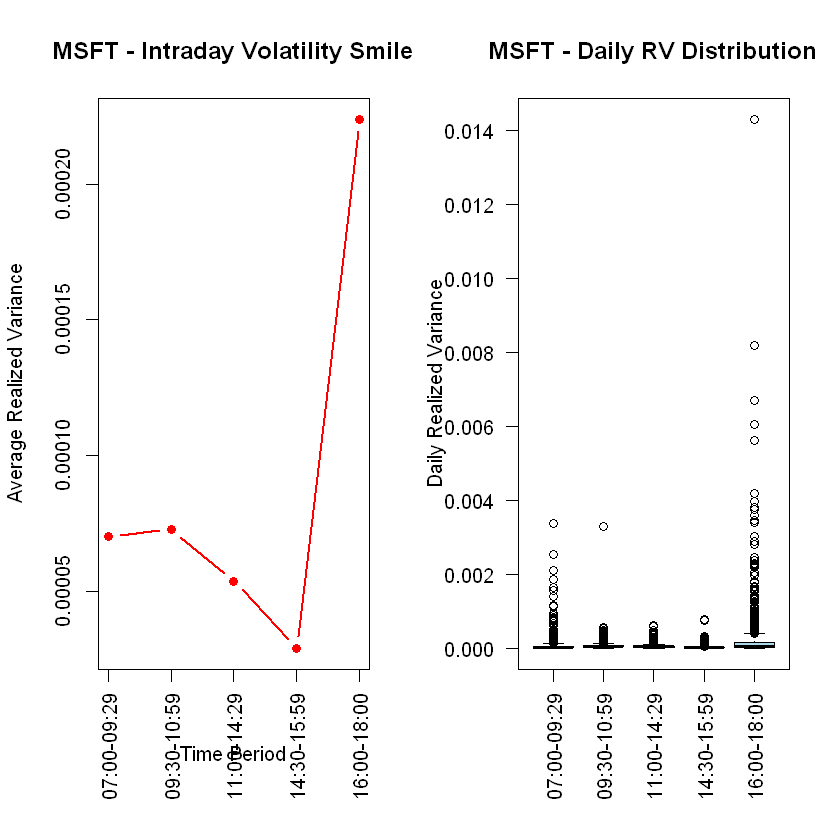


--- BAC Average Realized Variance by Period ---
07:00-09:29 : 0.000142
09:30-10:59 : 0.000130
11:00-14:29 : 0.000113
14:30-15:59 : 0.000051
16:00-18:00 : 0.000186


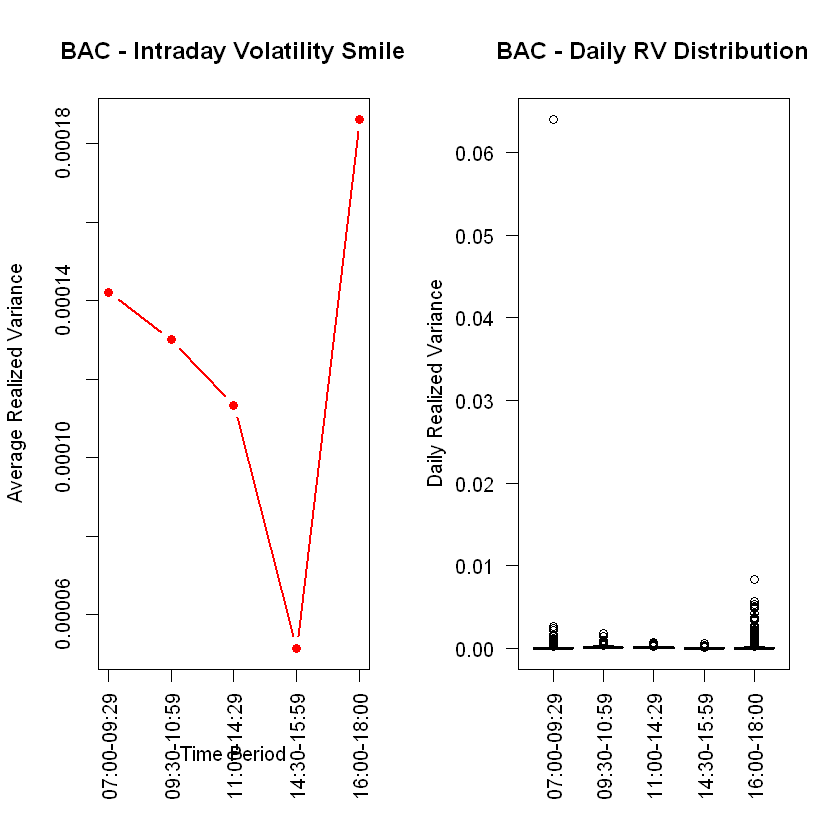


--- XOM Average Realized Variance by Period ---
07:00-09:29 : 0.000365
09:30-10:59 : 0.000070
11:00-14:29 : 0.000048
14:30-15:59 : 0.000023
16:00-18:00 : 0.000115


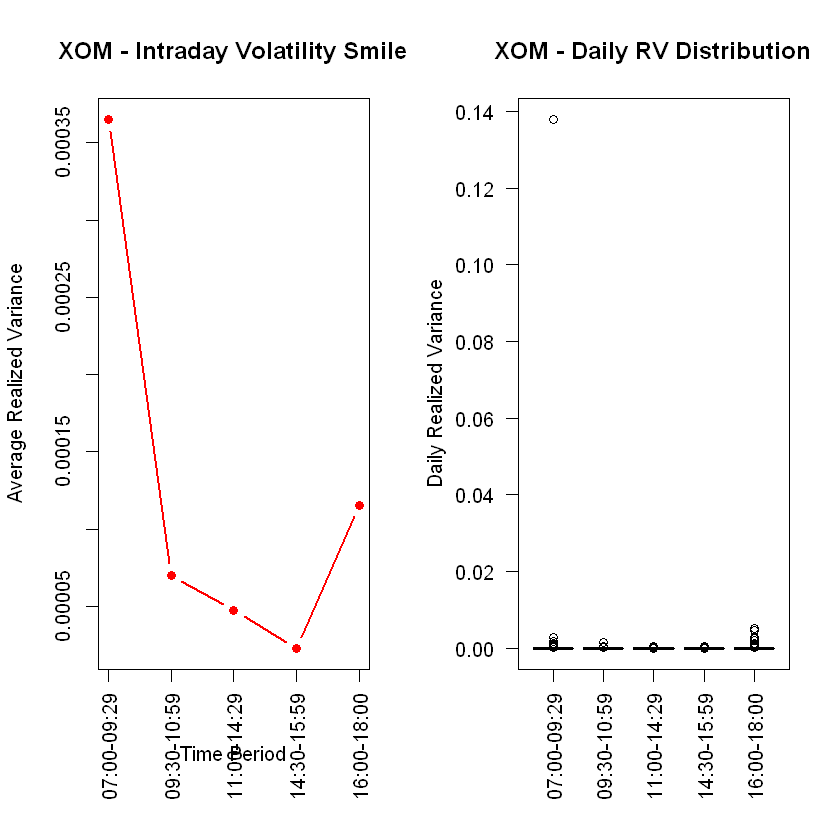

In [19]:
subperiod_msft <- compare_subperiod_rv(msft_clean, "MSFT")
subperiod_bac  <- compare_subperiod_rv(bac_clean,  "BAC")
subperiod_xom  <- compare_subperiod_rv(xom_clean,  "XOM")

In [26]:
compare_rv_additivity <- function(clean_data, ticker) {
  periods <- c("T07:00/T09:29", "T09:30/T10:59", "T11:00/T14:29",
               "T14:30/T15:59", "T16:00/T18:00")
 
  # Full daily RV must use the same 07:00-18:00 window as the sub-periods so
  # the comparison is symmetric. Using the raw Returns column without a time
  # filter would include returns outside this window, making the total
  # incomparable to the sub-period sum even when additivity holds perfectly.
  rv_daily <- rCov(na.omit(clean_data["T07:00/T18:00", "Returns"]), makeReturns = FALSE)
  index(rv_daily) <- as.Date(index(rv_daily))
  colnames(rv_daily) <- "Full_RV"
 
  combined_rvs <- rv_daily
  for (i in seq_along(periods)) {
    sub_ret      <- na.omit(clean_data[periods[i], "Returns"])
    daily_sub_rv <- rCov(sub_ret, makeReturns = FALSE)
    index(daily_sub_rv) <- as.Date(index(daily_sub_rv))
    colnames(daily_sub_rv) <- paste0("P", i)
    combined_rvs <- merge(combined_rvs, daily_sub_rv, join = "left")
  }
 
  combined_rvs[is.na(combined_rvs)] <- 0
 
  rv_summed <- rowSums(combined_rvs[, 2:6])
  rv_diff   <- combined_rvs[, 1] - rv_summed
 
  par(mar = c(7, 4, 4, 2) + 0.1)
  print(plot(rv_diff,
             main = paste(ticker, "Full RV vs. Summed RV"),
             col  = "darkgreen", ylab = "Difference"))
 
  cat(sprintf("\n--- %s Additivity Summary ---\n", ticker))
  cat(sprintf("Mean Difference: %e\n", mean(rv_diff, na.rm = TRUE)))
  cat(sprintf("Max Difference : %e\n", max(rv_diff,  na.rm = TRUE)))
  cat(sprintf("Min Difference : %e\n", min(rv_diff,  na.rm = TRUE)))
 
  return(list(
    rv_daily      = rv_daily,
    combined_rvs  = combined_rvs,
    rv_summed     = rv_summed,
    rv_diff       = rv_diff
  ))
}


--- MSFT Additivity Summary ---
Mean Difference: 2.513051e-22
Max Difference : 8.673617e-19
Min Difference : -8.673617e-19


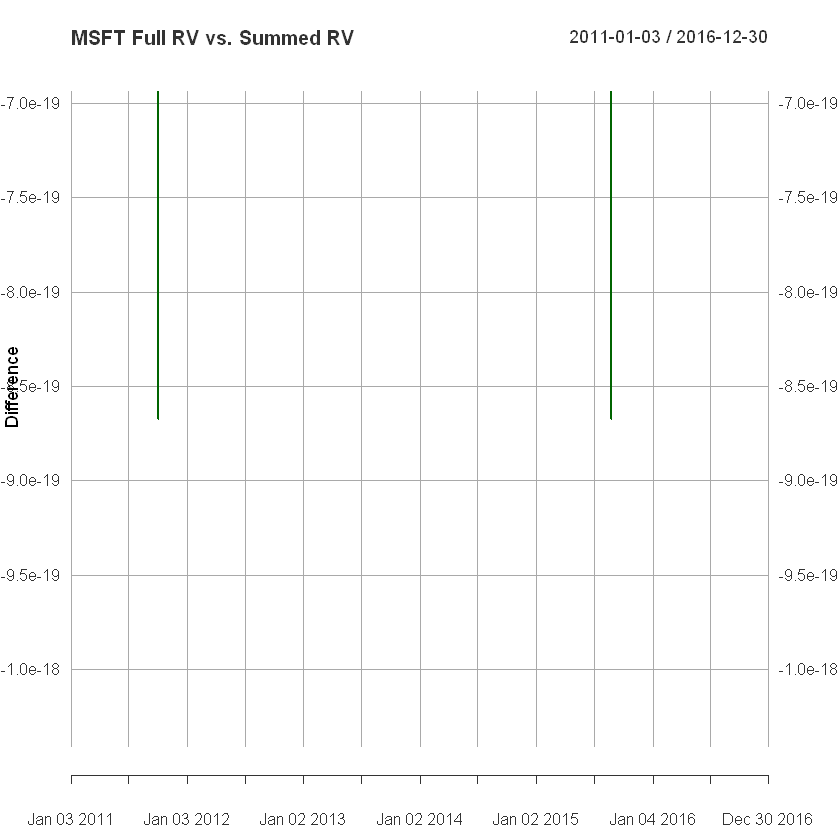


--- BAC Additivity Summary ---
Mean Difference: 1.249677e-21
Max Difference : 4.336809e-19
Min Difference : -8.673617e-19


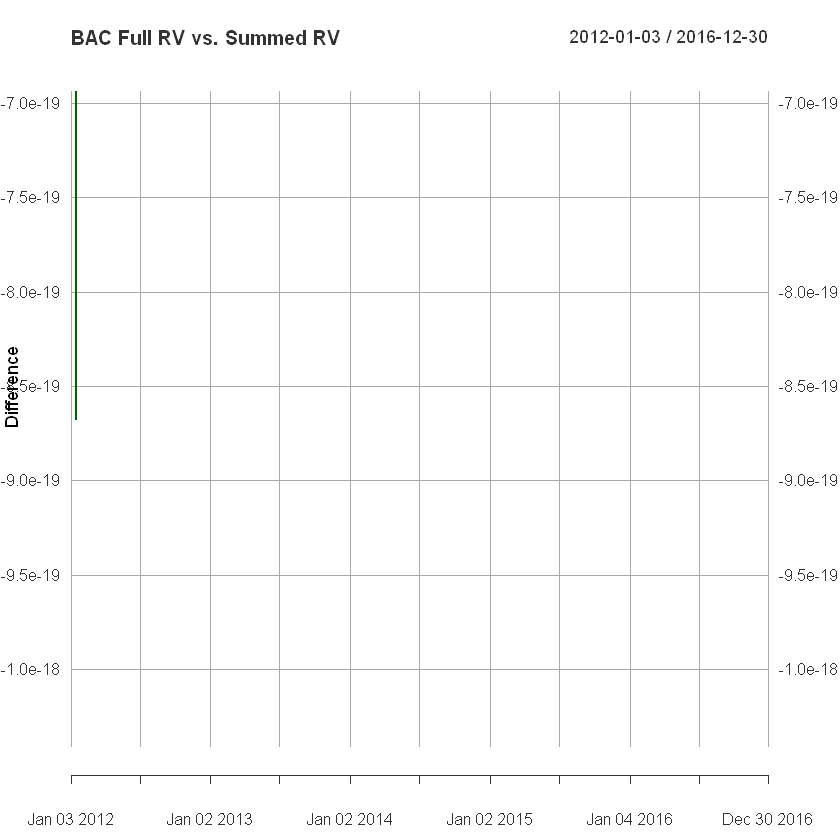


--- XOM Additivity Summary ---
Mean Difference: -5.399499e-20
Max Difference : 4.336809e-19
Min Difference : -2.775558e-17


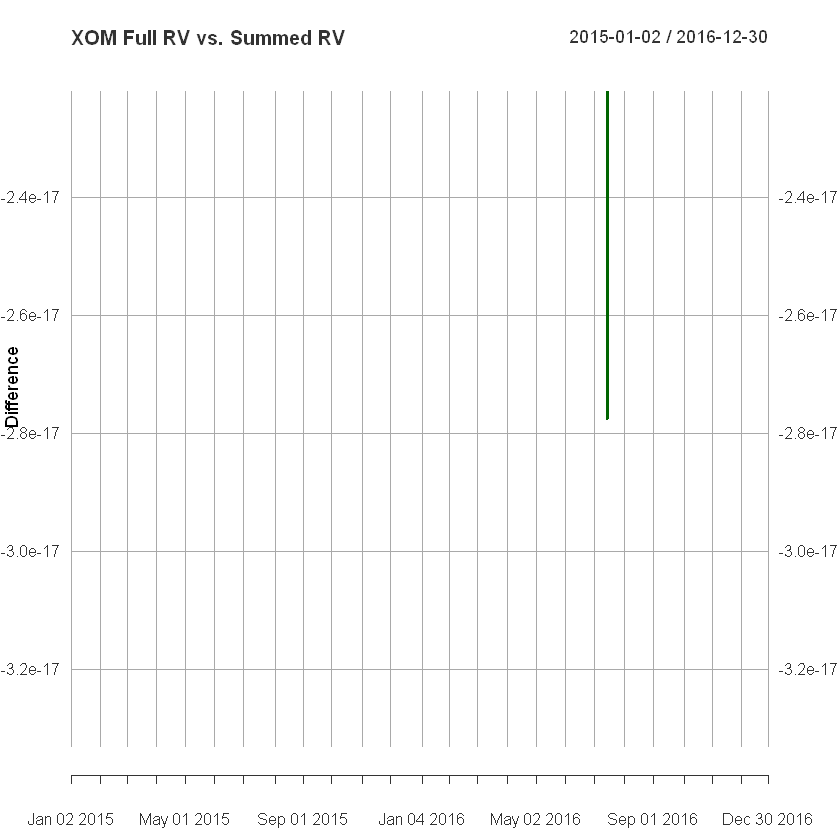

In [27]:
additivity_msft <- compare_rv_additivity(msft_clean, "MSFT")
additivity_bac  <- compare_rv_additivity(bac_clean,  "BAC")
additivity_xom  <- compare_rv_additivity(xom_clean,  "XOM")

In [22]:
plot_rv_shares <- function(clean_data, ticker) {
  periods <- list(
    "T07:00/T09:29" = "07:00-09:29",
    "T09:30/T10:59" = "09:30-10:59",
    "T11:00/T14:29" = "11:00-14:29",
    "T14:30/T15:59" = "14:30-15:59",
    "T16:00/T18:00" = "16:00-18:00"
  )
 
  # Use rCov directly on the time-filtered xts slice — it splits by day
  # internally, same as compare_subperiod_rv. Reassign index to plain Date
  # after each rCov call (seminar pattern) so merge() aligns correctly.
  rv_list <- lapply(names(periods), function(time_range) {
    sub_ret  <- na.omit(clean_data[time_range, "Returns"])
    daily_rv <- rCov(sub_ret, makeReturns = FALSE)
    index(daily_rv) <- as.Date(index(daily_rv))
    daily_rv
  })
 
  combined_rvs <- do.call(merge, rv_list)
  combined_rvs[is.na(combined_rvs)] <- 0
  colnames(combined_rvs) <- unlist(unname(periods))
 
  daily_total <- rowSums(combined_rvs)
  rv_shares   <- sweep(combined_rvs, 1, daily_total, FUN = "/") * 100
  rv_shares[daily_total == 0, ] <- 0
 
  mean_shares <- colMeans(rv_shares, na.rm = TRUE)
 
  bar_cols <- c("#2C7BB6", "#ABD9E9", "#FFFFBF", "#FDAE61", "#D7191C")
  bp <- barplot(mean_shares,
                main      = paste(ticker, "— Avg % Share of Intraday RV"),
                col       = bar_cols,
                ylim      = c(0, max(mean_shares, na.rm = TRUE) * 1.2),
                ylab      = "Percentage Share (%)",
                xlab      = "Intraday Period",
                las       = 2,
                border    = "white",
                cex.names = 0.85)
  text(x = bp, y = mean_shares,
       labels = paste0(round(mean_shares, 1), "%"),
       pos = 3, cex = 0.85, font = 2)
 
  cat(sprintf("\n=== %s — RV Share Breakdown ===\n", ticker))
  for (i in seq_along(mean_shares)) {
    cat(sprintf("  %-15s : %6.2f%%\n", names(mean_shares)[i], mean_shares[i]))
  }
  cat(sprintf("  %-15s : %6.2f%%\n", "TOTAL", sum(mean_shares)))
 
  return(list(
    combined_rvs = combined_rvs,
    daily_total  = daily_total,
    rv_shares    = rv_shares,
    mean_shares  = mean_shares
  ))
}


=== MSFT — RV Share Breakdown ===
  07:00-09:29     :  17.98%
  09:30-10:59     :  24.33%
  11:00-14:29     :  17.80%
  14:30-15:59     :   8.83%
  16:00-18:00     :  31.07%
  TOTAL           : 100.00%


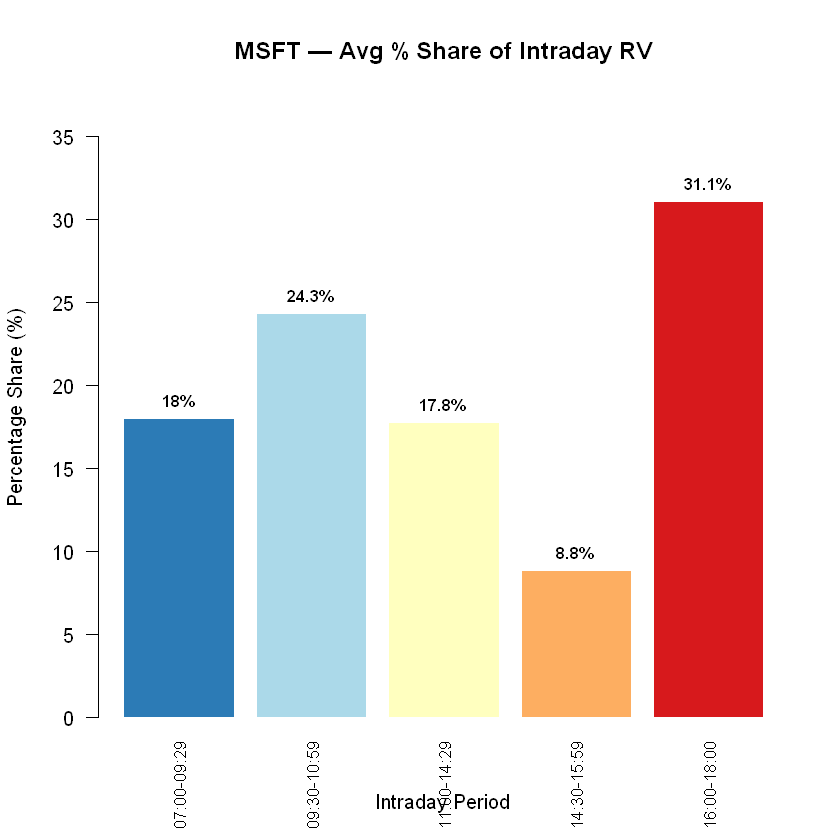


=== BAC — RV Share Breakdown ===
  07:00-09:29     :  17.24%
  09:30-10:59     :  29.13%
  11:00-14:29     :  25.05%
  14:30-15:59     :  10.90%
  16:00-18:00     :  17.68%
  TOTAL           : 100.00%


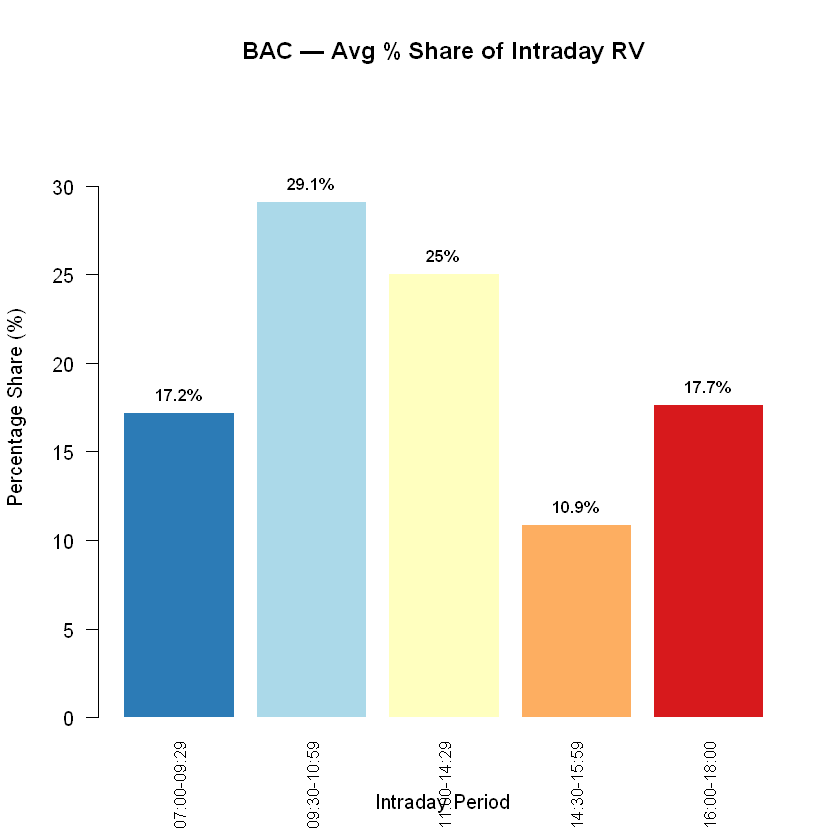


=== XOM — RV Share Breakdown ===
  07:00-09:29     :  25.35%
  09:30-10:59     :  27.03%
  11:00-14:29     :  18.70%
  14:30-15:59     :   8.12%
  16:00-18:00     :  20.79%
  TOTAL           : 100.00%


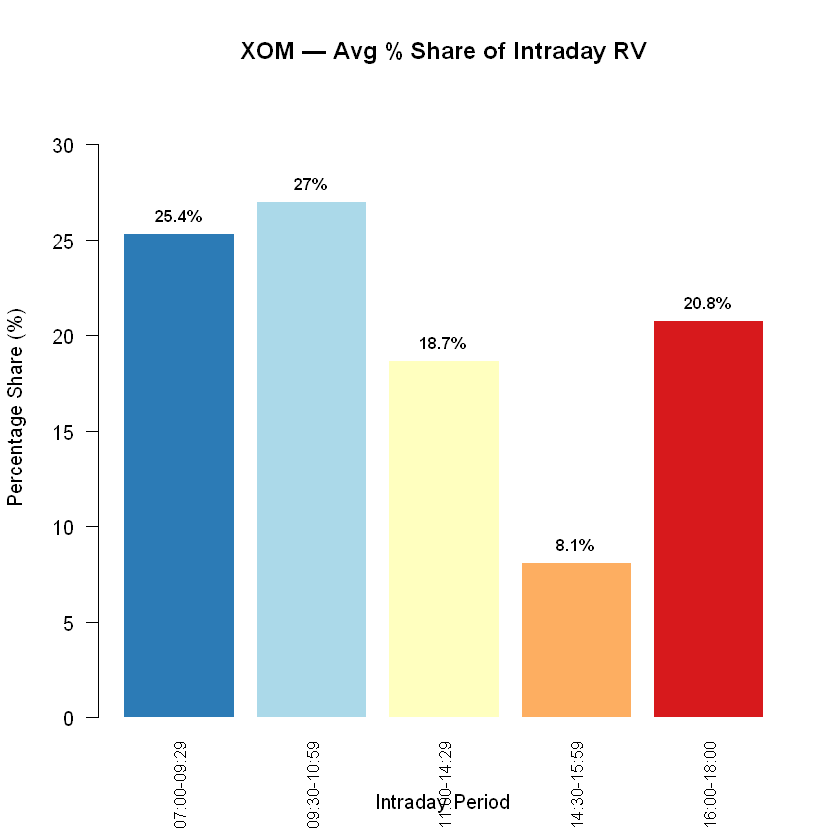

In [23]:
shares_msft <- plot_rv_shares(msft_clean, "MSFT")
shares_bac  <- plot_rv_shares(bac_clean,  "BAC")
shares_xom  <- plot_rv_shares(xom_clean,  "XOM")

In [24]:
compare_subperiod_rv_prices <- function(clean_data, ticker) {
  periods      <- c("T07:00/T09:29", "T09:30/T10:59", "T11:00/T14:29",
                    "T14:30/T15:59", "T16:00/T18:00")
  period_names <- c("07:00-09:29", "09:30-10:59", "11:00-14:29",
                    "14:30-15:59", "16:00-18:00")
 
  avg_rv        <- numeric(length(periods))
  daily_rv_list <- list()
 
  for (i in seq_along(periods)) {
    # Use Price column; rCov will call makeReturns internally
    sub_prices       <- clean_data[periods[i], "Price"]
    daily_rv         <- rCov(sub_prices, makeReturns = TRUE)
    index(daily_rv)  <- as.Date(index(daily_rv))
    daily_rv_list[[i]] <- as.numeric(daily_rv)
    avg_rv[i]        <- mean(daily_rv, na.rm = TRUE)
  }
  names(daily_rv_list) <- period_names
 
  par(mfrow = c(1, 2), mar = c(7, 4, 4, 2) + 0.1)
 
  plot(avg_rv, type = "b", pch = 16, col = "red", lwd = 2, xaxt = "n",
       main = paste(ticker, "- Intraday Volatility Smile (Prices)"),
       ylab = "Average Realized Variance", xlab = "Time Period")
  axis(1, at = 1:5, labels = period_names, las = 2)
 
  boxplot(daily_rv_list, names = period_names, col = "lightblue",
          main = paste(ticker, "- Daily RV Distribution (Prices)"),
          ylab = "Daily Realized Variance", las = 2)
 
  par(mfrow = c(1, 1))
 
  cat(sprintf("\n--- %s Average RV by Period (Prices) ---\n", ticker))
  for (i in seq_along(periods)) {
    cat(sprintf("%s : %f\n", period_names[i], avg_rv[i]))
  }
 
  return(list(
    avg_rv        = setNames(avg_rv, period_names),
    daily_rv_list = daily_rv_list
  ))
}

In [25]:
subperiod_prices_msft <- compare_subperiod_rv_prices(msft_clean, "MSFT")
subperiod_prices_bac  <- compare_subperiod_rv_prices(bac_clean,  "BAC")
subperiod_prices_xom  <- compare_subperiod_rv_prices(xom_clean,  "XOM")

ERROR: Error in x[(2:l), ]: subscript out of bounds


In [2]:
compare_rv_additivity_prices <- function(clean_data, ticker) {
  periods <- c("T07:00/T09:29", "T09:30/T10:59", "T11:00/T14:29",
               "T14:30/T15:59", "T16:00/T18:00")
 
  # Full daily RV from prices
  rv_daily <- rCov(clean_data[, "Price"], makeReturns = TRUE)
  index(rv_daily) <- as.Date(index(rv_daily))
  colnames(rv_daily) <- "Full_RV"
 
  combined_rvs <- rv_daily
  for (i in seq_along(periods)) {
    sub_prices   <- clean_data[periods[i], "Price"]
    daily_sub_rv <- rCov(sub_prices, makeReturns = TRUE)
    index(daily_sub_rv) <- as.Date(index(daily_sub_rv))
    colnames(daily_sub_rv) <- paste0("P", i)
    combined_rvs <- merge(combined_rvs, daily_sub_rv, join = "left")
  }
 
  combined_rvs[is.na(combined_rvs)] <- 0
 
  rv_summed <- rowSums(combined_rvs[, 2:6])
  rv_diff   <- combined_rvs[, 1] - rv_summed
 
  par(mar = c(7, 4, 4, 2) + 0.1)
  print(plot(rv_diff,
             main = paste(ticker, "Full RV vs. Summed RV (Prices)"),
             col  = "darkred", ylab = "Difference"))
 
  cat(sprintf("\n--- %s Additivity Summary (Prices) ---\n", ticker))
  cat(sprintf("Mean Difference: %e\n", mean(rv_diff, na.rm = TRUE)))
  cat(sprintf("Max Difference : %e\n", max(rv_diff,  na.rm = TRUE)))
  cat(sprintf("Min Difference : %e\n", min(rv_diff,  na.rm = TRUE)))
 
  return(list(
    rv_daily     = rv_daily,
    combined_rvs = combined_rvs,
    rv_summed    = rv_summed,
    rv_diff      = rv_diff
  ))
}

In [ ]:
additivity_prices_msft <- compare_rv_additivity_prices(msft_clean, "MSFT")
additivity_prices_bac  <- compare_rv_additivity_prices(bac_clean,  "BAC")
additivity_prices_xom  <- compare_rv_additivity_prices(xom_clean,  "XOM")

In [3]:
plot_rv_shares_prices <- function(clean_data, ticker) {
  periods <- list(
    "T07:00/T09:29" = "07:00-09:29",
    "T09:30/T10:59" = "09:30-10:59",
    "T11:00/T14:29" = "11:00-14:29",
    "T14:30/T15:59" = "14:30-15:59",
    "T16:00/T18:00" = "16:00-18:00"
  )
 
  rv_list <- lapply(names(periods), function(time_range) {
    sub_prices <- clean_data[time_range, "Price"]
    daily_rv   <- rCov(sub_prices, makeReturns = TRUE)
    index(daily_rv) <- as.Date(index(daily_rv))
    daily_rv
  })
 
  combined_rvs <- do.call(merge, rv_list)
  combined_rvs[is.na(combined_rvs)] <- 0
  colnames(combined_rvs) <- unlist(unname(periods))
 
  daily_total <- rowSums(combined_rvs)
  rv_shares   <- sweep(combined_rvs, 1, daily_total, FUN = "/") * 100
  rv_shares[daily_total == 0, ] <- 0
 
  mean_shares <- colMeans(rv_shares, na.rm = TRUE)
 
  bar_cols <- c("#2C7BB6", "#ABD9E9", "#FFFFBF", "#FDAE61", "#D7191C")
  bp <- barplot(mean_shares,
                main      = paste(ticker, "— Avg % Share of Intraday RV (Prices)"),
                col       = bar_cols,
                ylim      = c(0, max(mean_shares, na.rm = TRUE) * 1.2),
                ylab      = "Percentage Share (%)",
                xlab      = "Intraday Period",
                las       = 2,
                border    = "white",
                cex.names = 0.85)
  text(x = bp, y = mean_shares,
       labels = paste0(round(mean_shares, 1), "%"),
       pos = 3, cex = 0.85, font = 2)
 
  cat(sprintf("\n=== %s — RV Share Breakdown (Prices) ===\n", ticker))
  for (i in seq_along(mean_shares)) {
    cat(sprintf("  %-15s : %6.2f%%\n", names(mean_shares)[i], mean_shares[i]))
  }
  cat(sprintf("  %-15s : %6.2f%%\n", "TOTAL", sum(mean_shares)))
 
  return(list(
    combined_rvs = combined_rvs,
    daily_total  = daily_total,
    rv_shares    = rv_shares,
    mean_shares  = mean_shares
  ))
}

In [ ]:
shares_prices_msft <- plot_rv_shares_prices(msft_clean, "MSFT")
shares_prices_bac  <- plot_rv_shares_prices(bac_clean,  "BAC")
shares_prices_xom  <- plot_rv_shares_prices(xom_clean,  "XOM")